# Project Introduction
**Analyzing Delivery Performance and Order Trends in E-Commerce**


This dataset comes from the Brazilian e-commerce platform **Olist**. It contains information on approximately **100,000** orders from **2016 to 2018**, made across multiple marketplaces in Brazil. 

## Project Goals

1. **Evaluate seller delivery performance**  
   Compare slow vs fast sellers using delivery time metrics to identify potential inefficiencies in supplier fulfillment or warehouse operations.

2. **Assess delivery reliability and its impact on customer experience**  
   Measure the on-time delivery rate to understand how consistently delivery promises are met, which may influence customer satisfaction and retention.

3. **Identify high-demand shipping regions**  
   Analyze order distribution by region to support logistics planning, resource allocation, and strategic inventory placement.


Through this project, the goal is to identify key KPIs in supply chain to derive key business insights about e-commerence for Olist by visualizing our data in Tableau.

# Importing Libraries 

In [1]:
import sqlite3 
import numpy as np
import pandas as pd 

# List available files in every directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/liqiying411/maindata/archive/olist_customers_dataset.csv
/kaggle/input/datasets/liqiying411/maindata/archive/olist_sellers_dataset.csv
/kaggle/input/datasets/liqiying411/maindata/archive/olist_order_reviews_dataset.csv
/kaggle/input/datasets/liqiying411/maindata/archive/olist_order_items_dataset.csv
/kaggle/input/datasets/liqiying411/maindata/archive/olist_products_dataset.csv
/kaggle/input/datasets/liqiying411/maindata/archive/olist_geolocation_dataset.csv
/kaggle/input/datasets/liqiying411/maindata/archive/product_category_name_translation.csv
/kaggle/input/datasets/liqiying411/maindata/archive/olist_orders_dataset.csv
/kaggle/input/datasets/liqiying411/maindata/archive/olist_order_payments_dataset.csv
/kaggle/input/datasets/liqiying411/orders-ss/Screenshot 2026-03-18 143305.png
/kaggle/input/datasets/liqiying411/picture1/Screenshot 2026-03-05 170902.png


# Reading in data

In this project, we start by loading the Olist dataset into CSV files.

In [2]:
# Check current directory
print(os.getcwd())

conn = sqlite3.connect('olist.db')

# Load CSVs using pandas
path = "/kaggle/input/datasets/liqiying411/maindata/archive/"

customers = pd.read_csv(path + "olist_customers_dataset.csv")
geolocation = pd.read_csv(path + "olist_geolocation_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
order_payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")
orders = pd.read_csv(path + "olist_orders_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")
sellers = pd.read_csv(path + "olist_sellers_dataset.csv")
category_translation = pd.read_csv(path + "product_category_name_translation.csv")

/kaggle/working


# Data Cleaning

For this project, we focus on **four key tables:** `customers`, `order_items`, `orders`, and `sellers`.

## 1. `customers` -> `customers_cleaned`
- City-level names were too inconsistent to clean efficiently.
- For regional analysis, we aggregate by state using the **customer_state** abbreviation, which is standardized and reliable, and used in `sellers` table too.

In [3]:
print(customers.head())
print(customers.info())

# Find number of unique IDs in both columns
print(customers['customer_id'].nunique())
print(customers['customer_unique_id'].nunique())

# Drop `customer_city`, create `state_name` column
customers.drop(['customer_city'], axis=1, inplace=True)
# Rename `customer_state` into `state_abbr`
customers.rename(columns={'customer_state': 'state_abbr'}, inplace=True)

state_mapping = {
    'AC': 'Acre',
    'AL': 'Alagoas',
    'AP': 'Amapa',
    'AM': 'Amazonas',
    'BA': 'Bahia',
    'CE': 'Ceara',
    'DF': 'Distrito Federal',
    'ES': 'Espirito Santo',
    'GO': 'Goias',
    'MA': 'Maranhao',
    'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul',
    'MG': 'Minas Gerais',
    'PA': 'Para',
    'PB': 'Paraiba',
    'PR': 'Parana',
    'PE': 'Pernambuco',
    'PI': 'Piaui',
    'RJ': 'Rio de Janeiro',
    'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul',
    'RO': 'Rondonia',
    'RR': 'Roraima',
    'SC': 'Santa Catarina',
    'SP': 'Sao Paulo',
    'SE': 'Sergipe',
    'TO': 'Tocantins'
}
customers['state_name'] = customers['state_abbr'].map(state_mapping)

# Final cleaned state for customers
print(customers.head())

# Check missing values
print("Missing values per column:")
print(customers.isnull().sum())
# Check duplicate rows
print("Number of duplicate rows:", customers.duplicated().sum())

# Save cleaned dataset
customers_cleaned = customers
customers_cleaned.to_csv('customers_cleaned.csv', index=False)

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count

## 2. `order_items` -> `order_items_cleaned`
`order_items` is generally clean. 
- `shipping_limit_date` is converted to date type.
- Decided to keep the time portion (HH:MM:SS) for more precise comparison when we compare with other date columns.

In [4]:
order_items.info()
print(order_items.shape)
order_items.describe()

# Check missing values
print("Missing values per column:")
print(order_items.isnull().sum())
# Check duplicate rows
print("Number of duplicate rows:", order_items.duplicated().sum())

# Convert `shipping_limit_date` to date type
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

# Save cleaned dataset
order_items_cleaned = order_items
order_items_cleaned.to_csv('order_items_cleaned.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
(112650, 7)
Missing values per column:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
Number of duplicate rows: 0


## 3. `orders` -> `orders_cleaned`
The `orders` table contains multiple date columns, but we will only focus on:
- When the customer made the purchase **(order_purchase_timestamp)**
- When the order was delivered to the customer **(order_delivered_customer_date)**

Changes made to `orders`:
- Convert datatype of relevant columns from string to datetime
- Drop unnecessary timestamp columns
- Keep only orders with status = 'delivered'

In [5]:
orders.info()

# Check missing values
print("Missing values per column:")
print(orders.isnull().sum())
# Check duplicate rows
print("Number of duplicate rows:", orders.duplicated().sum())

# Drop irrelavent timestamp columns
orders = orders.drop(columns=['order_approved_at', 'order_delivered_carrier_date'])

# Convert `order_purchase_timestamp` and `order_delivered_customer_date` to date
date_col = ['order_purchase_timestamp',
            'order_delivered_customer_date']
for col in date_col:
    orders[col] = pd.to_datetime(orders[col])

# We are only interested in those orders delivered
orders = orders[orders['order_status'] == 'delivered']

# Check missing values
print("Missing values per column:")
print(orders.isnull().sum())
# Check duplicate rows
print("Number of duplicate rows:", orders.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
Missing values per column:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_d

### Handling mislabelled `order_status`
Some rows are incorrectly labelled as 'delivered' for order_status, they should be 'shipped'. (except row 92645)

To ensure accuracy, these rows are to be dropped from the dataset.

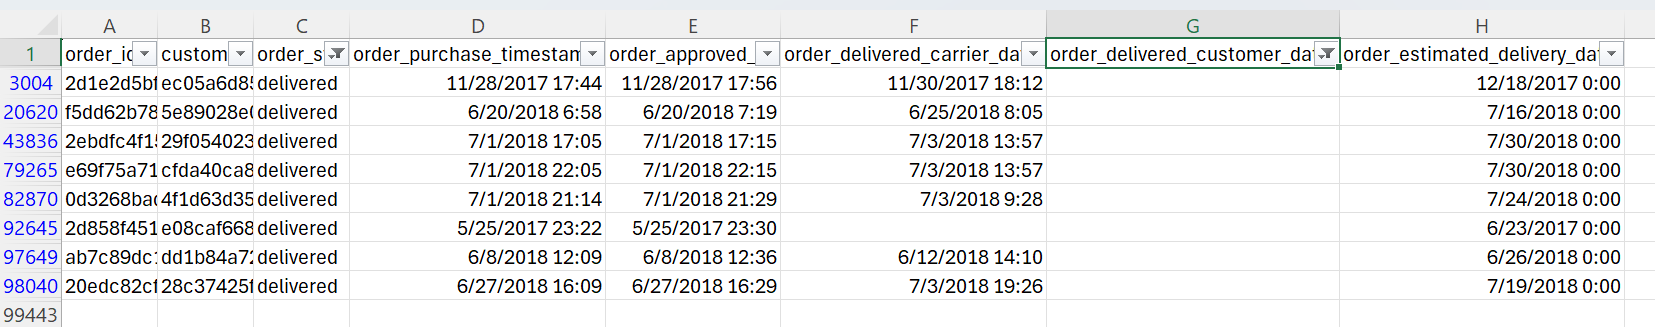

After this step, `orders_cleaned` contains only orders that were truly delivered.

In [6]:
# Drop rows with NA
orders_cleaned = orders.dropna(subset=['order_delivered_customer_date'])

# Check missing values
print("Missing values per column:")
print(orders_cleaned.isnull().sum())
# Check duplicate rows
print("Number of duplicate rows:", orders_cleaned.duplicated().sum())

# Save cleaned dataset
orders_cleaned.to_csv('orders_cleaned.csv', index=False)

Missing values per column:
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64
Number of duplicate rows: 0


## 4. `sellers` -> `sellers_cleaned`
The `sellers` dataset is generally clean. For our analysis, we are only comparing metrics by state, so some columns are unnecessary:

- seller_zip_code_prefix
- seller_city

These columns will be dropped..

In [7]:
sellers.info()

# Drop zip code prefix and city columns
sellers = sellers.drop(columns=['seller_zip_code_prefix', 'seller_city'])

# Check missing values
print("Missing values per column:")
print(sellers.isnull().sum())
# Check duplicate rows
print("Number of duplicate rows:", sellers.duplicated().sum())

# Save cleaned dataset
sellers_cleaned = sellers
sellers_cleaned.to_csv('sellers_cleaned.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB
Missing values per column:
seller_id       0
seller_state    0
dtype: int64
Number of duplicate rows: 0


# SQL
In the sections below, we will:  
1. Define the **key supply chain metrics** to analyze.  
2. Use **SQL queries** to extract the required data.  
3. Load the results into **Pandas DataFrames**.  
4. Export the data as `.csv` files for visualization in **Tableau**.

# Supply Chain Key Metrics

### 1. **Average Delivery Time per Seller (Days)**
- **Definition:** Measures the average time taken by a seller to deliver products to customers.  
- **Formula:**  
  `AVG(order_delivered_customer_date - order_purchase_timestamp)`  
- **Tables Used:** `orders`, `order_items`, `sellers`  

---

### 2. **On-Time Delivery Rate per Seller (%)**
- **Definition:** Percentage of orders delivered on or before the estimated delivery date.  
- **Formula:**  
  `(Number of On-Time Deliveries / Total Delivered Orders) * 100`  
- **Tables Used:** `orders`, `order_items`, `sellers`  

---

### 3. **Order Cycle Time**
- **Definition:** Total time taken from order placement to final delivery.  
- **Formula:**  
  `order_delivered_customer_date - order_purchase_timestamp`  
- **Tables Used:** `orders`  

---

### 4. **Order Volume by Region**
- **Definition:** Identifies regions (e.g., states or cities) with the highest number of orders.  
- **Purpose:** Helps optimize logistics, inventory allocation, and delivery planning.  
- **Tables Used:** `orders`, `customers`  

# Setting up SQL tables
In this step, we load the cleaned datasets into a SQL database connection (`conn`).  
Then, we will use **sqlite3** library to perform SQL queries directly on the data for analysis.

In [8]:
# Store dataframes to SQL database 'conn'
customers_cleaned.to_sql('customers', conn, index=False, if_exists='replace')
order_items_cleaned.to_sql('order_items', conn, index=False, if_exists='replace')
orders_cleaned.to_sql('orders', conn, index=False, if_exists='replace')
sellers_cleaned.to_sql('sellers', conn, index=False, if_exists='replace')

# Sample SQL query
query = """
SELECT c.customer_id, COUNT(o.order_id) AS total_orders
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_id
ORDER BY total_orders DESC
LIMIT 5;
"""

# Create Pandas Dataframe from Sample Query
df = pd.read_sql_query(query, conn)
print(df)

                        customer_id  total_orders
0  ffffa3172527f765de70084a7e53aae8             1
1  ffff42319e9b2d713724ae527742af25             1
2  fffeda5b6d849fbd39689bb92087f431             1
3  fffecc9f79fd8c764f843e9951b11341             1
4  fffcb937e9dd47a13f05ecb8290f4d3e             1


# SQL Queries to Measure KPIs
### 1. **Average Delivery Time per Seller (Days)**
- **Formula:**
  `AVG(order_delivered_customer_date - order_purchase_timestamp)`  

In [9]:
#SQL Query for Metric 1
query = """
SELECT 
    s.seller_id,
    s.seller_state,
    ROUND(AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)), 2) AS avg_delivery_days,
    COUNT(o.order_id) AS total_orders
FROM sellers s
INNER JOIN order_items oi ON s.seller_id = oi.seller_id
INNER JOIN orders o ON oi.order_id = o.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY s.seller_id, s.seller_state
ORDER BY avg_delivery_days ASC;
"""

# Create pd Dataframe from SQL Query
AvgDTPerSeller = pd.read_sql_query(query, conn)
print(AvgDTPerSeller)

# To compare distribution of `total_orders`
AvgDTPerSeller.describe()

                             seller_id seller_state  avg_delivery_days  \
0     139157dd4daa45c25b0807ffff348363           SP               1.21   
1     5e063e85d44b0f5c3e6ec3131103a57e           SP               1.29   
2     6561d6bf844e464b4019442692b40e02           SP               1.43   
3     702835e4b785b67a084280efca355756           MG               1.80   
4     2c00c85d30361cd2ced2969cffbbffa3           MG               1.87   
...                                ...          ...                ...   
2965  8629a7efec1aab257e58cda559f03ba7           GO              59.23   
2966  4fb41dff7c50136976d1a5cf004a42e2           BA              66.75   
2967  586a871d4f1221763fddb6ceefdeb95e           RS              68.62   
2968  8e670472e453ba34a379331513d6aab1           MG              86.00   
2969  df683dfda87bf71ac3fc63063fba369d           RS             189.86   

      total_orders  
0                1  
1                1  
2                1  
3                1  
4     

,avg_delivery_days,total_orders
count,2970.000000,2970.000000
mean,12.160451,37.100673
std,7.103132,119.672064
min,1.210000,1.000000
25%,8.290000,2.000000
50%,11.120000,8.000000
75%,14.240000,26.000000
max,189.860000,1996.000000


### Seller Segmentation by Order Volume

It is not meaningful to directly compare sellers with very few orders to those with a large number of orders.  
To ensure a fair comparison, we create a categorical column `seller_segment` based on total number of orders.

- **Low:** Fewer than 50 orders  
- **Medium:** 50 to 199 orders  
- **High:** 200 or more orders  

This segmentation allows us to analyze performance metrics (e.g., delivery time) more fairly across sellers of different scales.

In [10]:
# NEW SQL Query for Metric 1
query = """
WITH table1 AS
(SELECT 
    s.seller_id,
    s.seller_state,
    ROUND(AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)), 2) AS avg_delivery_days,
    COUNT(o.order_id) AS total_orders
FROM sellers s
INNER JOIN order_items oi ON s.seller_id = oi.seller_id
INNER JOIN orders o ON oi.order_id = o.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY s.seller_id, s.seller_state
ORDER BY avg_delivery_days ASC)

SELECT *, CASE 
        WHEN total_orders < 50 THEN 'Low'
        WHEN total_orders < 200 THEN 'Medium'
        ELSE 'High'
    END AS seller_segment
FROM table1
ORDER BY total_orders DESC;
"""

# Create pd Dataframe from SQL Query
AvgDTPerSeller = pd.read_sql_query(query, conn)
print(AvgDTPerSeller)

# Save dataset
AvgDTPerSeller.to_csv('avg_DT_per_seller.csv', index=False)

                             seller_id seller_state  avg_delivery_days  \
0     6560211a19b47992c3666cc44a7e94c0           SP               9.54   
1     4a3ca9315b744ce9f8e9374361493884           SP              14.42   
2     1f50f920176fa81dab994f9023523100           SP              15.57   
3     cc419e0650a3c5ba77189a1882b7556a           SP              11.54   
4     da8622b14eb17ae2831f4ac5b9dab84a           SP              11.17   
...                                ...          ...                ...   
2965  87f3e35268860433e13d577825aada95           SP              51.50   
2966  3da38366e7bd9baf6369071f782ecdf0           CE              53.35   
2967  8629a7efec1aab257e58cda559f03ba7           GO              59.23   
2968  8e670472e453ba34a379331513d6aab1           MG              86.00   
2969  df683dfda87bf71ac3fc63063fba369d           RS             189.86   

      total_orders seller_segment  
0             1996           High  
1             1949           High  
2  

## 2. **On-Time Delivery Rate per Seller (%)**

- **Formula:**  
  `(Number of On-Time Deliveries / Total Delivered Orders) * 100`

- **On-Time Condition:**  
  An order is considered **delivered on time** if:  
  `order_delivered_customer_date <= order_estimated_delivery_date`  

In [11]:
#SQL Query for Metric 2
query = """
SELECT 
    s.seller_id,
    s.seller_state,
    COUNT(o.order_id) AS total_delivered_orders,
    SUM(CASE 
        WHEN julianday(o.order_delivered_customer_date) <= julianday(o.order_estimated_delivery_date)
        THEN 1 ELSE 0 END) AS on_time_orders,
    ROUND(
        100.0 * SUM(CASE 
            WHEN julianday(o.order_delivered_customer_date) <= julianday(o.order_estimated_delivery_date)
            THEN 1 ELSE 0 END) 
        / COUNT(o.order_id), 2
    ) AS on_time_delivery_rate_pct
FROM sellers s
INNER JOIN order_items oi ON s.seller_id = oi.seller_id
INNER JOIN orders o ON oi.order_id = o.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY s.seller_id, s.seller_state
ORDER BY on_time_delivery_rate_pct DESC, total_delivered_orders DESC;
"""

# Create pd Dataframe from SQL Query
OTD_per_seller = pd.read_sql_query(query, conn)
print(OTD_per_seller)

# Save dataset
OTD_per_seller.to_csv('OTD_per_seller.csv', index=False)

                             seller_id seller_state  total_delivered_orders  \
0     fc906263ca5083d09dce42fe02247800           MG                     117   
1     9616352088dcf83a7c06637f4ebf1c80           PR                      97   
2     f3b80352b986ab4d1057a4b724be19d0           DF                      91   
3     b372ee768ed69e46ca8cdbd267aa7a38           SP                      69   
4     57e632711dec9ec14ca7546769483e7e           SC                      65   
...                                ...          ...                     ...   
2965  1b4b28463457a256e9a784ebe2a8f630           SP                       1   
2966  19484c79cef6c062cb177aa4ef2fcc3c           SP                       1   
2967  154bdf805377afea75a3bd158e9eab10           SP                       1   
2968  13d95f0f6f73943d4ceffad0fc2cd32c           GO                       1   
2969  05ca864204d09595ae591b93ea9cf93d           SP                       1   

      on_time_orders  on_time_delivery_rate_pct  
0

## 3. **Order Cycle Time**
- **Formula:**  
  `order_delivered_customer_date - order_purchase_timestamp`  

In [12]:
# SQL Query for Metric 3
query = """
SELECT
    order_id,
    ROUND(julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp), 2) AS order_cycle_days
FROM orders
WHERE order_delivered_customer_date IS NOT NULL
ORDER BY order_cycle_days DESC;
"""

# Create pd Dataframe from SQL Query
order_cycle_time = pd.read_sql_query(query, conn)
print(order_cycle_time)

# Save dataset
order_cycle_time.to_csv('order_cycle_time.csv', index=False)

# Compare distribution of order cycle time
order_cycle_time['order_cycle_days'].describe()

                               order_id  order_cycle_days
0      ca07593549f1816d26a572e06dc1eab6            209.63
1      1b3190b2dfa9d789e1f14c05b647a14a            208.35
2      440d0d17af552815d15a9e41abe49359            195.63
3      2fb597c2f772eca01b1f5c561bf6cc7b            194.85
4      285ab9426d6982034523a855f55a885e            194.63
...                                 ...               ...
96465  bb5a519e352b45b714192a02ffe25681              0.89
96466  f3c6775ba3d2d9fe2826f93b71f12008              0.86
96467  8339b608be0d84fca9d8da68b58332c3              0.86
96468  434cecee7d1a65fc65358a632b6f725f              0.78
96469  1d893dd7ca5f77ebf5f59f0d2017eee0              0.53

[96470 rows x 2 columns]


count    96470.000000
mean        12.558201
std          9.546155
min          0.530000
25%          6.770000
50%         10.220000
75%         15.720000
max        209.630000
Name: order_cycle_days, dtype: float64

## 4. **Orders Volume by Region**
- **Definition:** States or cities with the highest volume of orders.  

In [13]:
# SQL Query for Metric 4
query = """
SELECT 
    c.state_abbr,
    c.state_name,
    COUNT(o.order_id) AS total_orders
FROM orders o
INNER JOIN customers c
    ON o.customer_id = c.customer_id
GROUP BY c.state_abbr, c.state_name
ORDER BY total_orders DESC;
"""

# Create pd Dataframe from SQL Query
orders_by_region = pd.read_sql_query(query, conn)
print(orders_by_region)

# Save dataset
orders_by_region.to_csv('orders_by_region.csv', index=False)

   state_abbr           state_name  total_orders
0          SP            Sao Paulo         40494
1          RJ       Rio de Janeiro         12350
2          MG         Minas Gerais         11354
3          RS    Rio Grande do Sul          5344
4          PR               Parana          4923
5          SC       Santa Catarina          3546
6          BA                Bahia          3256
7          DF     Distrito Federal          2080
8          ES       Espirito Santo          1995
9          GO                Goias          1957
10         PE           Pernambuco          1593
11         CE                Ceara          1279
12         PA                 Para           946
13         MT          Mato Grosso           886
14         MA             Maranhao           717
15         MS   Mato Grosso do Sul           701
16         PB              Paraiba           517
17         PI                Piaui           476
18         RN  Rio Grande do Norte           474
19         AL       

### Further insights from `sellers`
The top 3 regions by order volume are:  
- `Sao Paulo`  
- `Rio de Janeiro`  
- `Minas Gerais`  

To gain deeper insights, we further analyze the **monthly order volume** for these regions in the most recent year available, **2018**.  

This helps us:  
- Identify seasonal trends in demand  
- Compare growth patterns across regions  
- Support better planning for logistics and inventory allocation  

In [14]:
# Second SQL Query for `sellers` table
query2 = """
SELECT 
    c.state_abbr,
    c.state_name,
    STRFTIME('%Y-%m', o.order_purchase_timestamp) AS order_month,
    COUNT(o.order_id) AS total_orders
FROM orders o
INNER JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_purchase_timestamp BETWEEN '2018-01-01' AND '2018-12-31'
GROUP BY c.state_abbr, c.state_name, order_month
ORDER BY c.state_abbr, order_month;
"""
# Create pd Dataframe from SQL Query
orders_by_region_by_month = pd.read_sql_query(query2, conn)
print(orders_by_region_by_month)

# Save dataset
orders_by_region_by_month.to_csv('orders_by_region_by_month.csv', index=False)

    state_abbr state_name order_month  total_orders
0           AC       Acre     2018-01             6
1           AC       Acre     2018-02             3
2           AC       Acre     2018-03             2
3           AC       Acre     2018-04             4
4           AC       Acre     2018-05             2
..         ...        ...         ...           ...
210         TO  Tocantins     2018-04            19
211         TO  Tocantins     2018-05            16
212         TO  Tocantins     2018-06            18
213         TO  Tocantins     2018-07            22
214         TO  Tocantins     2018-08            13

[215 rows x 4 columns]


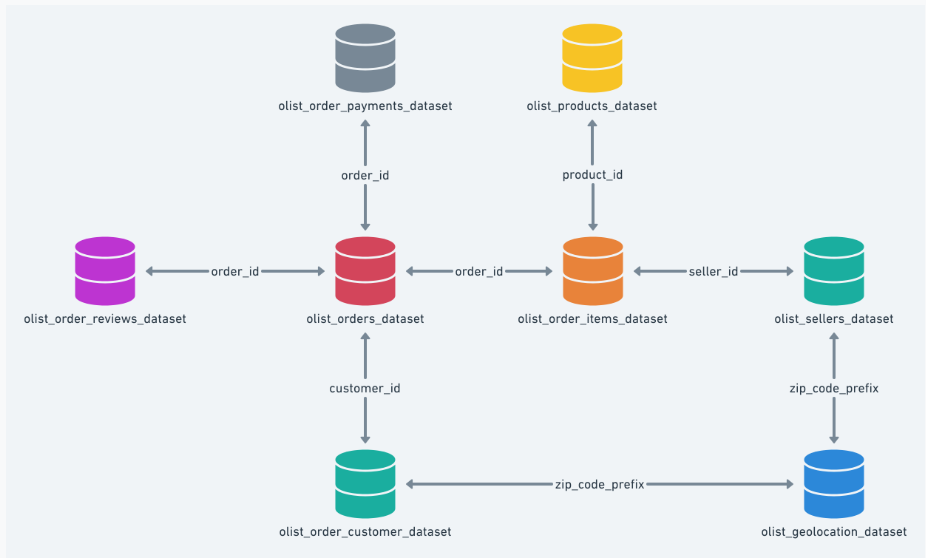